
# 06 - Q-Learning, SARSA, and Expected SARSA Algorithms

This portfolio notebook integrates the complete material from the two prepared notebooks:

1. **Q-Learning Portfolio Notebook**
   - reinforcement learning recap
   - RL components
   - exploration vs. exploitation
   - Q-Learning theory
   - six-state room problem
   - detailed manual calculations
   - first 60 Q-value updates
   - Q-table snapshots
   - both assignment experiments
   - convergence analysis
   - learned policies
   - connection to SARSA and Expected SARSA

2. **SARSA, Expected SARSA, and Q-Learning: TD Control on the Taxi Environment**
   - TD control
   - on-policy vs. off-policy
   - why off-policy learning is useful
   - SARSA
   - Expected SARSA
   - Q-Learning comparison
   - same-transition mathematical calculations
   - Taxi problem formulation
   - Gymnasium environment
   - first 60 updates for all three algorithms
   - reward vs. episode comparison
   - Q-table convergence
   - final learned Q-tables
   - greedy policies
   - evaluation
   - automatic best-agent selection
   - Taxi simulation
   - reinforcement learning hierarchy





## Structure

### Part I — Q-Learning Foundations and Six-State Assignment
This part develops Q-Learning from the RL basics through a complete tabular example and the two assignment experiments.

### Part II — SARSA, Expected SARSA, and Q-Learning on Taxi
This part extends TD control to SARSA and Expected SARSA, compares all three algorithms mathematically, and evaluates them on the same Taxi environment.

The progression is:

$$
\text{RL Foundations}
\rightarrow
\text{TD Control}
\rightarrow
\text{Q-Learning}
\rightarrow
\text{SARSA}
\rightarrow
\text{Expected SARSA}
\rightarrow
\text{Comparative Taxi Experiment}
$$



---

# Part I — Q-Learning Foundations





# 1. Reinforcement Learning Recap

Reinforcement Learning (RL) is a learning framework in which an **agent interacts with an environment** and learns how to make decisions from experience.

At time step $t$:

1. The agent observes the current state $S_t$.
2. The agent selects an action $A_t$.
3. The environment returns a reward $R_{t+1}$.
4. The environment moves to the next state $S_{t+1}$.
5. The interaction continues.

A compact representation is

$$
S_t \xrightarrow{A_t} (R_{t+1},S_{t+1}).
$$

The objective is to learn a policy that maximizes expected cumulative reward over time.



## 1.1 Reinforcement Learning vs. Supervised Learning

In supervised learning, a model is trained from examples containing inputs and desired outputs. A separate test phase is then used to evaluate how well the learned mapping generalizes to unseen data.

Examples of supervised-learning methods include random forests, support-vector machines, Bayesian classifiers, decision trees, and artificial neural networks when trained with labeled targets.

In reinforcement learning, the correct action is usually **not directly supplied as a label**. The agent interacts with the environment, takes actions, observes rewards and new states, and improves its behavior from experience.

Therefore, RL is not simply a classification or clustering procedure. Its central problem is **sequential decision-making through interaction**.



# 2. Main Components of Reinforcement Learning

## 2.1 State

A state $S_t$ represents the situation of the environment available to the agent at time $t$.

## 2.2 Action

An action $A_t$ is a decision the agent can take in the current state.

Depending on the problem, an action can be a single command or a higher-level movement composed of several low-level motions. The state and action spaces must therefore be defined carefully.

## 2.3 Policy

A policy describes how the agent selects actions.

For a stochastic policy,

$$
\pi(a|s)=P(A_t=a\mid S_t=s).
$$

A policy does not have to be optimal. During learning, the policy may deliberately choose non-greedy actions for exploration.

## 2.4 Reward Function

A reward is the numerical feedback produced after an action.

The reward function expresses what behavior the environment or designer wants to encourage or discourage. Poorly designed rewards can make learning slow or produce unwanted behavior.

## 2.5 Value Function

A value function evaluates long-term desirability rather than only immediate reward.

For this notebook, the most important quantity is the action-value function

$$
Q^\pi(s,a),
$$

which represents the expected return after taking action $a$ in state $s$ and then following policy $\pi$.

## 2.6 Model

A model describes how the environment responds to actions, for example through

$$
p(s',r\mid s,a).
$$

Some RL algorithms require a model and some do not. Q-learning is **model-free**.



## 2.7 Immediate Reward vs. Long-Term Return

The agent should not necessarily choose an action only because it gives the largest immediate reward.

The discounted return is

$$
G_t
=
R_{t+1}
+\gamma R_{t+2}
+\gamma^2R_{t+3}
+\cdots,
$$

where $0\le\gamma\le1$ is the discount factor.

An action with a small immediate reward may still be useful if it leads to better future rewards.



## 2.8 Learning Through Reward, Punishment, and Experience

Reinforcement learning is often compared with trial-and-error learning in natural agents such as people or animals.

The agent is not normally told exactly how to perform the best sequence of actions. Instead, it experiences consequences, receives rewards or penalties, and improves its decisions.

A typical experience sample has the form

$$
(S_t,A_t,R_{t+1},S_{t+1}).
$$

This is the information used by Q-learning to improve its action-value estimates.



## 2.9 Action and Reward Interaction

Unlike a standard supervised-learning dataset, RL examples are generated sequentially through interaction.

After the agent takes an action:

- the environment changes;
- a reward is observed;
- a new state is reached;
- the next decision depends on the new state.

The agent may initially have no idea which action is best. It must learn from its own experience in the state space.



## 2.10 How to Formulate an RL Problem

Before implementing an RL algorithm, ask:

- What exactly is a **state**?
- Is one action a single low-level command or a sequence of movements?
- What actions are available in each state?
- What is the policy?
- What reward should each transition receive?
- What value function will be learned?
- Is the task episodic or continuing?
- What is the terminal condition?

These choices define the learning problem. A poor state or action definition can make an otherwise correct algorithm ineffective.



# 3. Exploration vs. Exploitation

One of the main challenges in RL is balancing:

- **Exploration:** try different actions to discover their consequences.
- **Exploitation:** use current knowledge and choose an action that appears best.

If the agent always exploits, it may never discover a better action. If it explores too much, it may fail to use what it has already learned.

A common solution is the $\epsilon$-greedy policy:

$$
A_t=
\begin{cases}
\text{random valid action}, & \text{with probability }\epsilon,\\
\displaystyle\arg\max_a Q(S_t,a), & \text{with probability }1-\epsilon.
\end{cases}
$$

A common decay rule is

$$
\epsilon_{k+1}
=
\max(\epsilon_{\min},\lambda_\epsilon\epsilon_k).
$$

This allows more exploration early in training and more exploitation later.





# 4. Q-Learning

Q-learning was introduced by Christopher J. C. H. Watkins and later analyzed in the well-known Watkins and Dayan paper, *Q-learning*, published in *Machine Learning* in 1992.

Q-learning is a **model-free, off-policy, temporal-difference control algorithm**.

Its goal is to learn the optimal action-value function

$$
Q^*(s,a),
$$

which describes the long-term value of taking action $a$ in state $s$ and then behaving optimally.

The learned Q-values are not values manually assigned by the designer. The **rewards** are specified by the environment or problem designer; the **Q-values are learned from experience**.



## 4.1 Why Q-Learning Is Model-Free

Q-learning does not require the transition model

$$
p(s',r\mid s,a)
$$

to be known in advance.

It learns directly from sampled transitions

$$
(S_t,A_t,R_{t+1},S_{t+1}).
$$

This differs from dynamic programming, where state-transition probabilities and expected rewards are normally assumed to be available.



## 4.2 Why Q-Learning Is Off-Policy

The behavior policy can be $\epsilon$-greedy and therefore sometimes exploratory.

However, the Q-learning target uses the greedy value

$$
\max_{a'}Q(S_{t+1},a').
$$

So the agent may **behave** according to one policy while learning about a different greedy target policy.

This is why Q-learning is called **off-policy**.



# 5. Episodes and Terminal States

In an episodic environment, an episode starts from an initial state and ends when a terminal state is reached.

For example,

$$
C\rightarrow B\rightarrow D\rightarrow B\rightarrow F
$$

is one episode if $F$ is terminal.

After reaching the terminal state, learning for that episode stops and a new episode begins.

In the room problem used below, the slide uses a random initial state for the original experiment and state $F$ as the goal/terminal state.



# 6. Q-Table and Reward Table

For a small discrete problem, Q-learning can store one value for every state-action pair in a table.

The Q-table is commonly initialized with zeros:

$$
Q(s,a)=0.
$$

The **reward table** and the **Q-table** are different:

- $R(s,a)$ is determined by the environment.
- $Q(s,a)$ is learned by the agent.

The slide statement suggesting that the reward table can be initialized randomly or with zeros is better interpreted as referring to the **Q-table**. Rewards should represent the task definition.



# 7. Q-Learning Update Equation

The Q-learning update is

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma\max_{a'}Q(S_{t+1},a')
-
Q(S_t,A_t)
\right].
$$

The pieces are:

### Current estimate

$$
Q(S_t,A_t)
$$

### TD target

$$
R_{t+1}
+
\gamma\max_{a'}Q(S_{t+1},a')
$$

### TD error

$$
\delta_t
=
R_{t+1}
+
\gamma\max_{a'}Q(S_{t+1},a')
-
Q(S_t,A_t)
$$

### Update

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)+\alpha\delta_t.
$$



## 7.1 Learning Rate $\alpha$

The learning rate controls how strongly new information changes the current Q-value.

$$
0<\alpha\le1.
$$

- $\alpha=0$: the Q-value never changes.
- larger $\alpha$: new information receives more weight.
- smaller $\alpha$: updates are more conservative.

## 7.2 Discount Factor $\gamma$

The discount factor controls how strongly future value contributes to the target.

$$
0\le\gamma\le1.
$$

- $\gamma=0$: only the immediate reward contributes.
- larger $\gamma$: future rewards receive more weight.


# 8. Robot Charger Finding Problem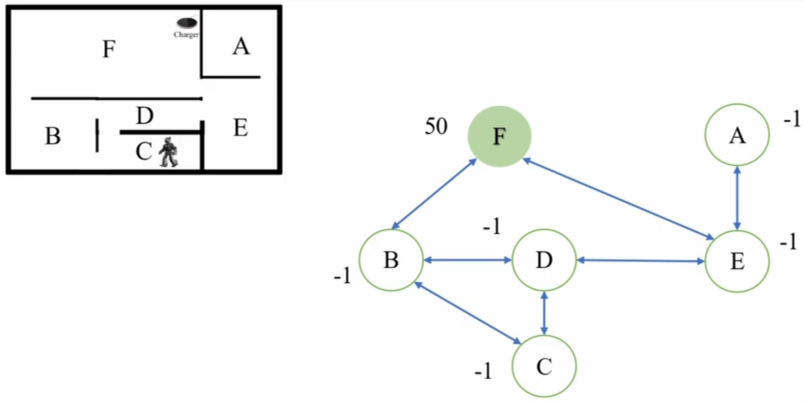

The states are

$$
\mathcal S=\{A,B,C,D,E,F\}.
$$

The available room-to-room movements are:

$$
A\leftrightarrow E
$$

$$
B\leftrightarrow D
$$

$$
B\leftrightarrow C
$$

$$
B\leftrightarrow F
$$

$$
C\leftrightarrow D
$$

$$
D\leftrightarrow E
$$

$$
E\leftrightarrow F.
$$

State $F$ contains the charger and is the original goal.

For this implementation:

- ordinary valid transitions receive reward $-1$;
- a transition into the goal receives reward $50$;
- invalid transitions are not selectable;
- when the goal is reached, the episode terminates.

The slides also draw a self-loop at $F$. Because $F$ is terminal, no additional transition is taken after entering it.


In [66]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

states = ["A", "B", "C", "D", "E", "F"]
state_to_idx = {s: i for i, s in enumerate(states)}

neighbors = {
    "A": ["E"],
    "B": ["C", "D", "F"],
    "C": ["B", "D"],
    "D": ["B", "C", "E"],
    "E": ["A", "D", "F"],
    "F": ["B", "E"]
}

def make_reward_table(goal="F", step_reward=-1.0, goal_reward=50.0):
    R = pd.DataFrame(np.nan, index=states, columns=states)
    for s in states:
        for s_next in neighbors[s]:
            R.loc[s, s_next] = goal_reward if s_next == goal else step_reward
    return R

R_F = make_reward_table(goal="F")
print("Reward table for target F:")
display(R_F)


Reward table for target F:


,A,B,C,D,E,F
A,NaN,NaN,NaN,NaN,-1.0,NaN
B,NaN,NaN,-1.0,-1.0,NaN,50.0
C,NaN,-1.0,NaN,-1.0,NaN,NaN
D,NaN,-1.0,-1.0,NaN,-1.0,NaN
E,-1.0,NaN,NaN,-1.0,NaN,50.0
F,NaN,-1.0,NaN,NaN,-1.0,NaN



In this notebook, an **action is represented by the destination state**. For example,

$$
Q(B,F)
$$

means:

> the learned value of being in state $B$ and choosing the action that moves to state $F$.

This matches the room-to-room interpretation in the lecture example.



# 9. Detailed Manual Q-Learning Calculations

The slide example uses

$$
\alpha=0.9
$$

and

$$
\gamma=0.8.
$$

Initially,

$$
Q(s,a)=0
$$

for every valid state-action pair.



## 9.1 Update 1: $B \rightarrow F$

$$
Q(s_t,a_t)
=
Q(s_t,a_t)
+
\alpha
\left[
R(s_t,a_t)
+
\gamma
\max_a Q(s_{t+1},a)
-
Q(s_t,a_t)
\right]
$$

$$
\begin{aligned}
Q(B,F)
&=
Q(B,F)
+
0.9
\left[
R(B,F)
+
0.8
\max_a
\left[
Q(F,B),Q(F,E),Q(F,F)
\right]
-
Q(B,F)
\right] \\[6pt]
&=
0
+
0.9
\left[
50
+
0.8
\max
\left[
0,0,0
\right]
-
0
\right] \\[6pt]
&=
45
\end{aligned}
$$

## 9.2 Update 2: $D \rightarrow B$

$$
Q(s_t,a_t)=Q(s_t,a_t)+\alpha[R(s_t,a_t)+\gamma \,\mathrm{Max}_a[Q(s_{t+1},a_{t+1})]-Q(s_t,a_t)]
$$

$$
Q(D,B)=Q(D,B)+0.9 * [R(D,B)+0.8 * \mathrm{Max}_a[Q(B,F),Q(B,D),Q(B,C)]-Q(D,B)]
$$

$$
=0+0.9 * [-1+0.8 * \mathrm{Max}[45,0,0]-0]=31.5
$$

## 9.3 Update 3: $B \rightarrow F$ Again

$$
Q(s_t,a_t)=Q(s_t,a_t)+\alpha[R(s_t,a_t)+\gamma \,\mathrm{Max}_a[Q(s_{t+1},a_{t+1})]-Q(s_t,a_t)]
$$

$$
Q(B,F)=Q(B,F)+0.9 * [R(B,F)+0.8 * \mathrm{Max}_a[Q(F,B),Q(F,E),Q(F,F)]-Q(B,F)]
$$

$$
=45+0.9 * [50+0.8 * \mathrm{Max}[0,0,0]-45]=49.5
$$

## 9.4 Update 4: $C \rightarrow B$

$$
Q(s_t,a_t)
=
Q(s_t,a_t)
+
\alpha
\left[
R(s_t,a_t)
+
\gamma \max_a Q(s_{t+1},a)
-
Q(s_t,a_t)
\right]
$$

$$
Q(C,B)
=
Q(C,B)
+
0.9
*
[R(C,B)
+
0.8
*
\max_a[Q(B,D),Q(B,F)]
-
Q(C,B)]
$$

$$
=
0
+
0.9
*
[-1
+
0.8
*
\max[0,49.5]
-
0]
=
34.74
$$

In [67]:

alpha_demo = 0.9
gamma_demo = 0.8

Q_demo = pd.DataFrame(0.0, index=states, columns=states)

def terminal_bootstrap(next_state, Q, terminal="F"):
    if next_state == terminal:
        return 0.0
    valid = neighbors[next_state]
    return max(Q.loc[next_state, a] for a in valid)

manual_steps = [("B", "F"), ("D", "B"), ("B", "F"), ("C", "B")]
manual_records = []

for i, (s, s_next) in enumerate(manual_steps, start=1):
    r = 50.0 if s_next == "F" else -1.0
    old_q = Q_demo.loc[s, s_next]
    max_next = terminal_bootstrap(s_next, Q_demo, terminal="F")
    target = r + gamma_demo * max_next
    td_error = target - old_q
    new_q = old_q + alpha_demo * td_error
    Q_demo.loc[s, s_next] = new_q
    manual_records.append([i, s, s_next, r, max_next, old_q, target, td_error, new_q])

manual_df = pd.DataFrame(
    manual_records,
    columns=["Update", "State", "Action/Next State", "Reward", "Max Next Q", "Old Q", "TD Target", "TD Error", "New Q"]
)

print("Mathematically consistent sequence using one continuously updated Q-table:")
display(manual_df)
print("Q-table after the four sequential updates:")
display(Q_demo)


Mathematically consistent sequence using one continuously updated Q-table:


,Update,State,Action/Next State,Reward,Max Next Q,Old Q,TD Target,TD Error,New Q
0,1,B,F,50.0,0.0,0.0,50.0,50.0,45.00
1,2,D,B,-1.0,45.0,0.0,35.0,35.0,31.50
2,3,B,F,50.0,0.0,45.0,50.0,5.0,49.50
3,4,C,B,-1.0,49.5,0.0,38.6,38.6,34.74


Q-table after the four sequential updates:


,A,B,C,D,E,F
A,0.0,0.00,0.0,0.0,0.0,0.0
B,0.0,0.00,0.0,0.0,0.0,49.5
C,0.0,34.74,0.0,0.0,0.0,0.0
D,0.0,31.50,0.0,0.0,0.0,0.0
E,0.0,0.00,0.0,0.0,0.0,0.0
F,0.0,0.00,0.0,0.0,0.0,0.0



# 10. Q-Learning Algorithm

```text
Input:
    state space S
    valid actions A(s)
    reward function R
    learning rate alpha
    discount factor gamma
    exploration rate epsilon
    number of episodes

Initialize:
    Q(s,a) = 0 for all valid state-action pairs

For episode = 1 to n_episodes:

    Choose the initial state s

    Repeat:

        With probability epsilon:
            choose a random valid action a
        Otherwise:
            choose a = argmax Q(s,a)

        Execute action a
        Observe reward r and next state s'

        If s' is terminal:
            target = r
        Else:
            target = r + gamma * max over a' Q(s',a')

        TD_error = target - Q(s,a)

        Q(s,a) = Q(s,a) + alpha * TD_error

        s = s'

    Until s is terminal

    Optionally decay epsilon
```



# 11. From-Scratch Python Implementation

The implementation below records every update so that the evolution of the Q-table can be inspected instead of jumping directly to the final result.


In [68]:

def train_q_learning(
    goal="F",
    n_episodes=800,
    alpha=0.9,
    gamma=0.8,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.99,
    random_start=True,
    fixed_start=None,
    seed=7
):
    rng = np.random.default_rng(seed)
    Q = pd.DataFrame(0.0, index=states, columns=states)
    R = make_reward_table(goal=goal)

    update_log = []
    convergence = []
    episode_returns = []
    epsilon = epsilon_start
    update_number = 0

    nonterminal_states = [s for s in states if s != goal]

    for episode in range(1, n_episodes + 1):
        Q_before = Q.copy()

        if fixed_start is not None:
            s = fixed_start
        elif random_start:
            s = rng.choice(nonterminal_states)
        else:
            s = nonterminal_states[0]

        total_reward = 0.0
        step = 0

        while s != goal and step < 100:
            step += 1
            valid_actions = neighbors[s]

            if rng.random() < epsilon:
                action = rng.choice(valid_actions)
                selection = "explore"
            else:
                q_values = np.array([Q.loc[s, a] for a in valid_actions], dtype=float)
                best_value = np.max(q_values)
                best_actions = [a for a, q in zip(valid_actions, q_values) if np.isclose(q, best_value)]
                action = rng.choice(best_actions)
                selection = "exploit"

            s_next = action
            r = float(R.loc[s, s_next])
            old_q = float(Q.loc[s, action])

            if s_next == goal:
                max_next_q = 0.0
                target = r
            else:
                max_next_q = max(float(Q.loc[s_next, a]) for a in neighbors[s_next])
                target = r + gamma * max_next_q

            td_error = target - old_q
            new_q = old_q + alpha * td_error
            Q.loc[s, action] = new_q

            update_number += 1
            update_log.append({
                "Update": update_number,
                "Episode": episode,
                "Step": step,
                "State": s,
                "Action/Next State": action,
                "Selection": selection,
                "Reward": r,
                "Max Next Q": max_next_q,
                "Old Q": old_q,
                "TD Target": target,
                "TD Error": td_error,
                "New Q": new_q,
                "Epsilon": epsilon
            })

            total_reward += r
            s = s_next

        q_change = np.max(np.abs(Q.to_numpy() - Q_before.to_numpy()))
        convergence.append(q_change)
        episode_returns.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, R, pd.DataFrame(update_log), np.array(convergence), np.array(episode_returns)

Q_F, R_F, updates_F, conv_F, returns_F = train_q_learning(
    goal="F",
    n_episodes=800,
    alpha=0.9,
    gamma=0.8,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.99,
    random_start=True,
    seed=7
)

print("Training complete.")
print("Number of recorded Q-value updates:", len(updates_F))


Training complete.
Number of recorded Q-value updates: 1526



# 12. First 60 Individual Q-Value Updates

The table below shows the first **60 individual updates**.

For every update it reports:

- episode and step;
- current state;
- selected action / next state;
- whether the action came from exploration or exploitation;
- reward;
- maximum next-state Q-value;
- old Q-value;
- TD target;
- TD error;
- new Q-value;
- current $\epsilon$.


In [69]:

pd.set_option("display.max_rows", 70)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 20)

display(updates_F.head(60).round(4))


,Update,Episode,Step,State,Action/Next State,Selection,Reward,Max Next Q,Old Q,TD Target,TD Error,New Q,Epsilon
0,1,1,1,E,D,explore,-1.0,0.000,0.000,-1.000,-1.000e+00,-0.900,1.000
1,2,1,2,D,E,explore,-1.0,0.000,0.000,-1.000,-1.000e+00,-0.900,1.000
2,3,1,3,E,A,explore,-1.0,0.000,0.000,-1.000,-1.000e+00,-0.900,1.000
3,4,1,4,A,E,explore,-1.0,0.000,0.000,-1.000,-1.000e+00,-0.900,1.000
4,5,1,5,E,D,explore,-1.0,0.000,-0.900,-1.000,-1.000e-01,-0.990,1.000
5,6,1,6,D,E,explore,-1.0,0.000,-0.900,-1.000,-1.000e-01,-0.990,1.000
6,7,1,7,E,F,explore,50.0,0.000,0.000,50.000,5.000e+01,45.000,1.000
7,8,2,1,B,F,explore,50.0,0.000,0.000,50.000,5.000e+01,45.000,0.990
8,9,3,1,B,D,explore,-1.0,0.000,0.000,-1.000,-1.000e+00,-0.900,0.980
9,10,3,2,D,C,explore,-1.0,0.000,0.000,-1.000,-1.000e+00,-0.900,0.980



# 13. Q-Table Snapshots During Learning

Instead of looking only at the final table, the next cell reconstructs the Q-table after selected update numbers:

$$
1,\;5,\;10,\;20,\;30,\;40,\;50,\;60.
$$


In [70]:

def reconstruct_snapshots(update_df, snapshot_updates):
    Q = pd.DataFrame(0.0, index=states, columns=states)
    snapshots = {}
    target_set = set(snapshot_updates)

    for _, row in update_df.iterrows():
        Q.loc[row["State"], row["Action/Next State"]] = row["New Q"]
        u = int(row["Update"])
        if u in target_set:
            snapshots[u] = Q.copy()
        if u >= max(snapshot_updates):
            break

    return snapshots

snapshot_updates = [1, 5, 10, 20, 30, 40, 50, 60]
snapshots = reconstruct_snapshots(updates_F, snapshot_updates)

for u in snapshot_updates:
    print(f"Q-table after update {u}")
    display(snapshots[u].round(3))


Q-table after update 1


,A,B,C,D,E,F
A,0.0,0.0,0.0,0.0,0.0,0.0
B,0.0,0.0,0.0,0.0,0.0,0.0
C,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,0.0
E,0.0,0.0,0.0,-0.9,0.0,0.0
F,0.0,0.0,0.0,0.0,0.0,0.0


Q-table after update 5


,A,B,C,D,E,F
A,0.0,0.0,0.0,0.00,-0.9,0.0
B,0.0,0.0,0.0,0.00,0.0,0.0
C,0.0,0.0,0.0,0.00,0.0,0.0
D,0.0,0.0,0.0,0.00,-0.9,0.0
E,-0.9,0.0,0.0,-0.99,0.0,0.0
F,0.0,0.0,0.0,0.00,0.0,0.0


Q-table after update 10


...

,A,B,C,D,E,F
A,0.000,0.000,0.000,0.000,34.65,0.00
B,0.000,0.000,28.786,30.118,0.00,49.95
C,0.000,38.205,0.000,29.514,0.00,0.00
D,0.000,38.953,29.558,0.000,37.88,0.00
E,-1.638,0.000,0.000,26.275,0.00,49.95
F,0.000,0.000,0.000,0.000,0.00,0.00


Q-table after update 50


,A,B,C,D,E,F
A,0.000,0.000,0.000,0.000,38.988,0.000
B,0.000,0.000,28.786,30.118,0.000,49.995
C,0.000,38.885,0.000,30.097,0.000,0.000
D,0.000,38.953,29.563,0.000,37.880,0.000
E,26.677,0.000,0.000,29.773,0.000,49.995
F,0.000,0.000,0.000,0.000,0.000,0.000


Q-table after update 60


,A,B,C,D,E,F
A,0.000,0.000,0.000,0.000,38.988,0.000
B,0.000,0.000,30.169,30.118,0.000,50.000
C,0.000,38.988,0.000,30.198,0.000,0.000
D,0.000,39.000,29.563,0.000,37.880,0.000
E,26.677,0.000,0.000,29.773,0.000,49.995
F,0.000,0.000,0.000,0.000,0.000,0.000



# 14.

**Implement the discussed environment in Python and report the Q-table values and a convergence plot. Choose enough episodes to show convergence.**

The experiment above uses:

$$
\alpha=0.9,\qquad
\gamma=0.8,
$$

an $\epsilon$-greedy behavior policy, decaying $\epsilon$, random nonterminal starting states, and target state $F$.


In [71]:

def masked_q_table(Q):
    shown = Q.copy().astype(object)
    for s in states:
        for a in states:
            if a not in neighbors[s]:
                shown.loc[s, a] = "—"
            else:
                shown.loc[s, a] = round(float(Q.loc[s, a]), 3)
    return shown

print("Final Q-table for target F:")
display(masked_q_table(Q_F))


Final Q-table for target F:


,A,B,C,D,E,F
A,—,—,—,—,39.0,—
B,—,—,30.2,30.2,—,50.0
C,—,39.0,—,30.2,—,—
D,—,39.0,30.2,—,39.0,—
E,30.2,—,—,30.2,—,50.0
F,—,0.0,—,—,0.0,—


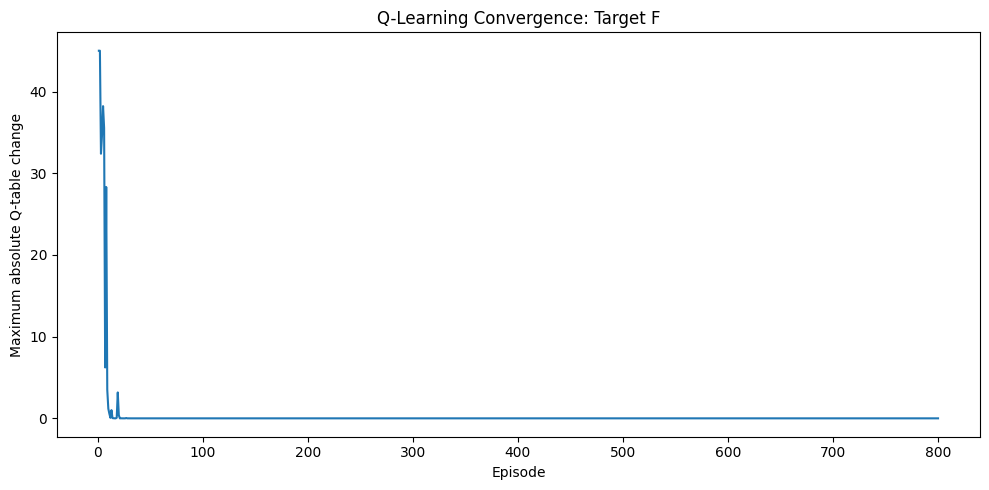

In [72]:

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(conv_F) + 1), conv_F)
plt.xlabel("Episode")
plt.ylabel("Maximum absolute Q-table change")
plt.title("Q-Learning Convergence: Target F")
plt.tight_layout()
plt.show()



## 14.1 Extracting the Learned Greedy Policy

After learning, a greedy policy is obtained from

$$
\pi^*(s)=\arg\max_aQ(s,a).
$$


In [73]:

def greedy_policy(Q, goal):
    policy = {}
    for s in states:
        if s == goal:
            policy[s] = "TERMINAL"
            continue
        valid_actions = neighbors[s]
        best = max(valid_actions, key=lambda a: Q.loc[s, a])
        policy[s] = best
    return policy

policy_F = greedy_policy(Q_F, goal="F")
print("Greedy policy for target F:")
for s in states:
    print(f"{s} -> {policy_F[s]}")


Greedy policy for target F:
A -> E
B -> F
C -> B
D -> B
E -> F
F -> TERMINAL


In [74]:

def greedy_path(Q, start, goal, max_steps=20):
    path = [start]
    s = start
    visited = set()

    for _ in range(max_steps):
        if s == goal:
            return path
        valid_actions = neighbors[s]
        best = max(valid_actions, key=lambda a: Q.loc[s, a])
        path.append(best)
        s = best

        state_key = tuple(path[-4:]) if len(path) >= 4 else tuple(path)
        if state_key in visited:
            break
        visited.add(state_key)

    return path

print("Example greedy paths to F:")
for start in ["A", "B", "C", "D", "E"]:
    print(f"{start}: {' -> '.join(greedy_path(Q_F, start, 'F'))}")


Example greedy paths to F:
A: A -> E -> F
B: B -> F
C: C -> B -> F
D: D -> B -> F
E: E -> F



# 15.

**Change the initial state to $A$ and the target state to $C$, then report the Q-table and convergence plot.**

For this experiment:

$$
S_0=A
$$

and

$$
S_{\text{goal}}=C.
$$

The graph remains the same, but the reward function is changed so that a valid transition into state $C$ receives the goal reward $50$. Other valid movements receive $-1$.

Each training episode starts from $A$.


In [75]:

Q_C, R_C, updates_C, conv_C, returns_C = train_q_learning(
    goal="C",
    n_episodes=800,
    alpha=0.9,
    gamma=0.8,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.99,
    random_start=False,
    fixed_start="A",
    seed=7
)

print("Reward table for target C:")
display(R_C)

print("Final Q-table for initial state A and target C:")
display(masked_q_table(Q_C))


Reward table for target C:


,A,B,C,D,E,F
A,NaN,NaN,NaN,NaN,-1.0,NaN
B,NaN,NaN,50.0,-1.0,NaN,-1.0
C,NaN,-1.0,NaN,-1.0,NaN,NaN
D,NaN,-1.0,50.0,NaN,-1.0,NaN
E,-1.0,NaN,NaN,-1.0,NaN,-1.0
F,NaN,-1.0,NaN,NaN,-1.0,NaN


Final Q-table for initial state A and target C:


,A,B,C,D,E,F
A,—,—,—,—,30.2,—
B,—,—,50.0,39.0,—,30.2
C,—,0.0,—,0.0,—,—
D,—,39.0,50.0,—,30.2,—
E,23.16,—,—,39.0,—,30.2
F,—,39.0,—,—,30.2,—


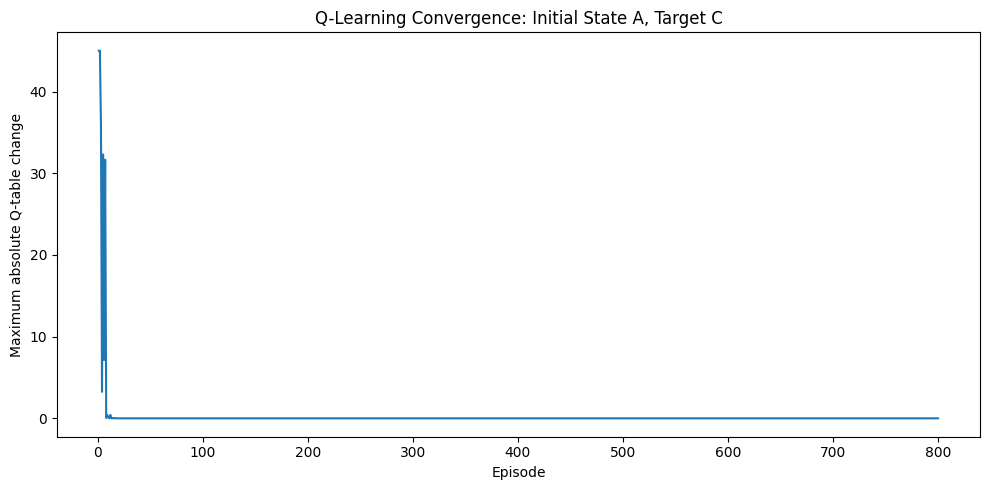

In [76]:

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(conv_C) + 1), conv_C)
plt.xlabel("Episode")
plt.ylabel("Maximum absolute Q-table change")
plt.title("Q-Learning Convergence: Initial State A, Target C")
plt.tight_layout()
plt.show()


In [77]:

policy_C = greedy_policy(Q_C, goal="C")
print("Greedy policy for target C:")
for s in states:
    print(f"{s} -> {policy_C[s]}")

print("\nGreedy path from A to C:")
print(" -> ".join(greedy_path(Q_C, "A", "C")))


Greedy policy for target C:
A -> E
B -> C
C -> TERMINAL
D -> C
E -> D
F -> B

Greedy path from A to C:
A -> E -> D -> C



# 16. Comparing the Two Experiments

The two experiments use the same state-transition graph and Q-learning algorithm, but the goal definition changes.

### Experiment 1

- random nonterminal initial state;
- target state $F$;
- reward $50$ for entering $F$.

### Experiment 2

- initial state fixed at $A$;
- target state $C$;
- reward $50$ for entering $C$.

Changing the goal changes the reward structure, which changes the learned Q-values and therefore changes the greedy policy.


In [78]:

comparison = pd.DataFrame({
    "Experiment": ["Target F", "Start A, Target C"],
    "Episodes": [len(conv_F), len(conv_C)],
    "Final max |ΔQ|": [conv_F[-1], conv_C[-1]],
    "Mean return, last 50 episodes": [returns_F[-50:].mean(), returns_C[-50:].mean()]
})
display(comparison.round(4))


,Experiment,Episodes,Final max |ΔQ|,"Mean return, last 50 episodes"
0,Target F,800,0.0,49.40
1,"Start A, Target C",800,0.0,47.96



---

# Part II — SARSA, Expected SARSA, and Q-Learning on the Taxi Environment




# SARSA, Expected SARSA, and Q-Learning: TD Control on the Taxi Environment

This notebook studies three tabular **Temporal-Difference (TD) control** algorithms:

- **SARSA**
- **Expected SARSA**
- **Q-Learning**

The notebook first explains the mathematical difference among the three methods, then applies all three to the same Taxi environment so that the comparison is fair.

### What this notebook will do

1. Review TD control and action-value learning.
2. Explain **on-policy** and **off-policy** learning.
3. Derive the SARSA, Expected SARSA, and Q-Learning updates.
4. Work through the **same numerical state-action example** with all three algorithms.
5. Introduce the Taxi problem, its state space, action space, rewards, and terminal condition.
6. Train all three algorithms using the same environment and hyperparameters.
7. Show the first **60 update steps** so the Q-values can be followed directly.
8. Compare reward versus episode.
9. Compare Q-table convergence.
10. Display the final learned Q-tables and greedy policies.
11. Evaluate all three algorithms on unseen episodes.
12. Automatically select the best-performing trained agent and simulate one greedy episode.

> The modern maintained successor to OpenAI Gym is **Gymnasium**. This notebook uses the Gymnasium API and automatically tries the current Taxi version first while retaining compatibility with Taxi-v3.

## 1. From TD Prediction to TD Control

In TD prediction, we estimate the value of states while following a policy.

For control, the goal is different: the agent must learn **which action to take** in each state.

Therefore, the main quantity is the action-value function

$$
Q^\pi(s,a),
$$

which represents the expected return obtained by taking action $a$ in state $s$ and then following policy $\pi$.

A general one-step TD control update can be written as

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
\text{TD Target}
-
Q(S_t,A_t)
\right].
$$

The three algorithms in this notebook differ mainly in how they define the **TD target**.

## 2. On-Policy and Off-Policy Learning

Two policies are useful when discussing TD control.

### Behavior policy

The **behavior policy** determines the action the agent actually uses to interact with the environment.

We denote it by

$$
b(a|s).
$$

For example, the behavior policy can be an $\epsilon$-greedy policy.

### Target policy

The **target policy** is the policy whose action values the algorithm is trying to learn.

We denote it by

$$
\pi(a|s).
$$

### On-policy

An algorithm is **on-policy** when it learns about the same policy it uses to generate behavior.

SARSA is the standard example.

### Off-policy

An algorithm is **off-policy** when its behavior policy and target policy can be different.

Q-Learning is the standard example: the agent can behave $\epsilon$-greedily, but its update uses the greedy action value in the next state.

## 2.1 Why Use Off-Policy Learning?

Off-policy learning separates the **behavior policy** used to collect experience from the **target policy** being learned.

This separation can be useful in several ways.

### Continuous exploration

The behavior policy can continue exploring while the target policy becomes increasingly greedy.

For example, the agent may collect experience using an $\epsilon$-greedy behavior policy,

$$
b(a|s),
$$

while learning about a greedier target policy,

$$
\pi(a|s).
$$

This allows the agent to continue visiting different state-action pairs without forcing the target policy itself to remain highly exploratory.

### Learning from demonstrations or previously collected experience

Because the behavior policy and target policy do not have to be identical, an off-policy method can learn from transitions generated by another policy.

The experience may come from:

- a human or expert demonstration,
- another agent,
- a previously saved dataset,
- an older version of the policy.

A transition still has the familiar form

$$
(S_t,A_t,R_{t+1},S_{t+1}),
$$

even when $A_t$ was selected by a policy different from the one currently being learned.

### Parallel and offline experience collection

Multiple workers or simulations can generate experience using different behavior policies, while the learning algorithm updates a common target policy.

Similarly, a fixed dataset can be collected first and used later for learning.

This separation is one reason off-policy ideas are useful in replay-based and offline reinforcement learning methods.

> Q-Learning is the main off-policy method in this notebook because its update uses the greedy next-state value even when the behavior policy used exploration.

## 3. Exploration and Exploitation

The algorithms need to balance:

- **Exploration:** try actions that may not currently look best.
- **Exploitation:** use the action that currently has the largest estimated value.

An $\epsilon$-greedy policy is

$$
A_t=
\begin{cases}
\text{random action}, & \text{with probability }\epsilon,\\
\arg\max_a Q(S_t,a), & \text{with probability }1-\epsilon.
\end{cases}
$$

If there is one greedy action and there are $|\mathcal A|$ actions, its probability under the usual $\epsilon$-greedy rule is

$$
1-\epsilon+\frac{\epsilon}{|\mathcal A|},
$$

while each nongreedy action has probability

$$
\frac{\epsilon}{|\mathcal A|}.
$$

During training, we will decay $\epsilon$ so that the agent explores more early and exploits more later.

# 4. Q-Learning

Q-Learning is a **model-free, off-policy TD control** algorithm.

Its update is

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma
\max_a Q(S_{t+1},a)
-
Q(S_t,A_t)
\right].
$$

The TD target is

$$
\boxed{
R_{t+1}
+
\gamma
\max_a Q(S_{t+1},a)
}
$$

and the TD error is

$$
\delta_t
=
R_{t+1}
+
\gamma
\max_a Q(S_{t+1},a)
-
Q(S_t,A_t).
$$

The important point is that Q-Learning uses the **largest next-state Q-value**, even if the behavior policy actually chooses another action.

# 5. SARSA

**SARSA** stands for

$$
\boxed{\text{State} \rightarrow \text{Action} \rightarrow \text{Reward} \rightarrow \text{State} \rightarrow \text{Action}}
$$

or

$$
(S_t,A_t,R_{t+1},S_{t+1},A_{t+1}).
$$

SARSA is a **model-free, on-policy TD control** algorithm.

Its update is

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1})
-
Q(S_t,A_t)
\right].
$$

The TD target is

$$
\boxed{
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1})
}
$$

where $A_{t+1}$ is the action actually selected from the current behavior policy, usually $\epsilon$-greedy.

This is why SARSA is **on-policy**: the update depends on the same policy that generates the agent's behavior.

## 5.1 SARSA Algorithm

```text
Input:
    learning rate alpha
    discount factor gamma
    exploration rate epsilon
    number of episodes

Initialize:
    Q(s,a) = 0 for every state-action pair

For each episode:

    Initialize state S

    Choose action A from S using epsilon-greedy

    Repeat:

        Take action A

        Observe reward R and next state S'

        If S' is terminal:

            target = R

            Q(S,A) = Q(S,A) + alpha * [target - Q(S,A)]

            Stop the episode

        Otherwise:

            Choose next action A' from S' using epsilon-greedy

            target = R + gamma * Q(S',A')

            Q(S,A) = Q(S,A) + alpha * [target - Q(S,A)]

            S = S'
            A = A'

Until the episode terminates
```

# 6. Expected SARSA

Expected SARSA replaces SARSA's single sampled next action with the **expected Q-value over all possible next actions** under a target policy.

Its update is

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma
\sum_a
\pi(a|S_{t+1})Q(S_{t+1},a)
-
Q(S_t,A_t)
\right].
$$

The TD target is

$$
\boxed{
R_{t+1}
+
\gamma
\sum_a
\pi(a|S_{t+1})Q(S_{t+1},a)
}
$$

For an $\epsilon$-greedy target policy, the expectation uses the probability of every action.

Expected SARSA often has lower target variance than ordinary SARSA because it averages over possible next actions instead of relying on one sampled $A_{t+1}$. It requires more computation per update because all next-action values are considered.

In this notebook, Expected SARSA uses the **same $\epsilon$-greedy behavior and target policy**, so it is used in its on-policy form.

## 6.1 Expected SARSA Algorithm

```text
Input:
    learning rate alpha
    discount factor gamma
    exploration rate epsilon
    number of episodes

Initialize:
    Q(s,a) = 0 for every state-action pair

For each episode:

    Initialize state S

    Repeat:

        Choose action A from S using epsilon-greedy

        Take action A

        Observe reward R and next state S'

        If S' is terminal:

            target = R

        Otherwise:

            Compute epsilon-greedy action probabilities pi(a|S')

            expected_Q = sum over a [pi(a|S') * Q(S',a)]

            target = R + gamma * expected_Q

        Q(S,A) = Q(S,A) + alpha * [target - Q(S,A)]

        S = S'

    Until the episode terminates
```

# 7. The Main Difference Among the Three Algorithms

All three methods update the same current value,

$$
Q(S_t,A_t),
$$

but use different information from the next state.

| Algorithm | Next-state quantity in the TD target | Policy type |
|---|---|---|
| Q-Learning | $\max_a Q(S_{t+1},a)$ | Off-policy |
| SARSA | $Q(S_{t+1},A_{t+1})$ | On-policy |
| Expected SARSA | $\sum_a \pi(a|S_{t+1})Q(S_{t+1},a)$ | On-policy here |

The difference can be summarized as

$$
\boxed{
\text{Max} \quad \text{vs.} \quad
\text{Sampled Action} \quad \text{vs.} \quad
\text{Expected Action Value}
}
$$

# 8. Same State-Action Calculation for Q-Learning, SARSA, and Expected SARSA

To see the difference clearly, use the **same robot-finding-charger transition** for all three algorithms.

Assume:

$$
S_t=D,
\qquad
A_t=B,
\qquad
R_{t+1}=-1,
\qquad
S_{t+1}=B.
$$

Assume the current value is

$$
Q(D,B)=31.5.
$$

At the next state $B$, the robot has three possible actions:

$$
B\rightarrow F,
\qquad
B\rightarrow D,
\qquad
B\rightarrow C.
$$

Suppose the current Q-values are

$$
Q(B,:)=[49.5,\;0,\;0],
$$

where

$$
Q(B,F)=49.5,
\qquad
Q(B,D)=0,
\qquad
Q(B,C)=0.
$$

Use

$$
\alpha=0.9,
\qquad
\gamma=0.8,
\qquad
\epsilon=0.10.
$$

For SARSA, suppose the next action selected by the $\epsilon$-greedy behavior policy is

$$
A_{t+1}=D,
$$

which means the robot selects

$$
B\rightarrow D.
$$

Therefore,

$$
Q(B,D)=0.
$$

## 8.1 Q-Learning Calculation

Q-Learning uses

$$
\max_a Q(B,a)=49.5.
$$

Therefore,

$$
\begin{aligned}
Q(D,B)
&\leftarrow
31.5
+
0.9
\left[
-1
+
0.8(49.5)
-
31.5
\right]\\
&=
31.5
+
0.9(7.1)\\
&=
\boxed{37.89}.
\end{aligned}
$$

Its TD target is

$$
-1+0.8(49.5)=\boxed{38.6}.
$$

## 8.2 SARSA Calculation

SARSA uses the value of the **next action actually selected**.

Suppose the robot selects

$$
B \rightarrow D,
$$

so

$$
Q(B,D)=0.
$$

Therefore,

$$
\begin{aligned}
Q(D,B)
&\leftarrow
31.5
+
0.9
\left[
-1
+
0.8(0)
-
31.5
\right]\\
&=
31.5
+
0.9(-32.5)\\
&=
\boxed{2.25}.
\end{aligned}
$$

Its TD target is

$$
-1+0.8(0)=\boxed{-1}.
$$

## 8.3 Expected SARSA Calculation

There are three possible actions from state $B$:

$$
B\rightarrow F,
\qquad
B\rightarrow D,
\qquad
B\rightarrow C.
$$

With $\epsilon=0.10$ and one greedy action, each nongreedy action receives

$$
\frac{0.10}{3}
=
0.033333.
$$

The greedy action receives

$$
1-0.10+\frac{0.10}{3}
=
0.933333.
$$

Since $B\rightarrow F$ has the largest Q-value,

$$
Q(B,:)=[49.5,\;0,\;0],
$$

the action probabilities are approximately

$$
[0.933333,\;0.033333,\;0.033333].
$$

The expected next-state value is

$$
\begin{aligned}
\mathbb E_\pi[Q(B,A)]
&=
0.933333(49.5)
+
0.033333(0)
+
0.033333(0)\\
&=
\boxed{46.2}.
\end{aligned}
$$

Therefore,

$$
\begin{aligned}
Q(D,B)
&\leftarrow
31.5
+
0.9
\left[
-1
+
0.8(46.2)
-
31.5
\right]\\
&=
31.5
+
0.9(4.46)\\
&=
\boxed{35.514}.
\end{aligned}
$$

Its TD target is

$$
-1+0.8(46.2)=\boxed{35.96}.
$$

For the **same transition $D\rightarrow B$**, the three algorithms give different updates because they use different bootstrap values.

# 9. Taxi Problem

The Taxi task is a small discrete control problem.

A taxi moves in a $5\times5$ grid. There are four designated locations:

- **R**: Red
- **G**: Green
- **Y**: Yellow
- **B**: Blue

At the beginning of an episode:

1. the taxi starts at a grid location,
2. the passenger starts at one of the designated locations,
3. the passenger has a destination.

The taxi must:

1. navigate to the passenger,
2. pick up the passenger,
3. navigate to the destination,
4. drop off the passenger correctly.

A successful drop-off terminates the episode.

## 9.1 State Space

The observation space contains **500 encoded states**.

A state combines:

- taxi row: $5$ possibilities,
- taxi column: $5$ possibilities,
- passenger location: $5$ possibilities,
- destination: $4$ possibilities.

Therefore,

$$
5\times5\times5\times4=500.
$$

The passenger-location value has five possibilities because the passenger may be at Red, Green, Yellow, Blue, or already inside the taxi.

The encoded observation is

$$
s
=
((\text{taxi row}\times5+\text{taxi column})\times5+\text{passenger location})\times4+\text{destination}.
$$

## 9.2 Action Space

Taxi has six discrete actions:

| Action | Meaning |
|---:|---|
| 0 | Move South |
| 1 | Move North |
| 2 | Move East |
| 3 | Move West |
| 4 | Pick up passenger |
| 5 | Drop off passenger |

Thus,

$$
|\mathcal A|=6.
$$

## 9.3 Reward Function

The standard Taxi reward structure is:

$$
R=
\begin{cases}
+20, & \text{successful passenger delivery},\\
-10, & \text{illegal pickup or drop-off},\\
-1, & \text{ordinary time step}.
\end{cases}
$$

The step penalty encourages the taxi to complete the task using fewer actions.

In this notebook we **do not use action masking** during training. This means the algorithms must learn from the environment's penalties instead of being prevented from attempting invalid actions.

## 9.4 Terminal and Truncated Episodes

An episode terminates when the passenger is successfully dropped off at the destination.

The environment can also truncate an episode when its maximum time limit is reached.

During TD updates:

- true terminal transitions use only the immediate reward as the target,
- nonterminal transitions bootstrap from the next state's Q-values.

# 10. Install and Import the Required Libraries

Run this cell in Google Colab.

The notebook uses **Gymnasium**, the maintained successor to OpenAI Gym.

In [79]:
!pip -q install "gymnasium[toy-text]" imageio

In [80]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import imageio.v2 as imageio

from IPython.display import display, Image

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# 11. Create and Inspect the Taxi Environment

Gymnasium 1.3 introduced Taxi-v4. The cell below tries Taxi-v4 first and falls back to Taxi-v3 for compatibility with older installations.

Environment: Taxi-v4
Observation space: Discrete(500)
Action space: Discrete(6)
Initial encoded state: 386


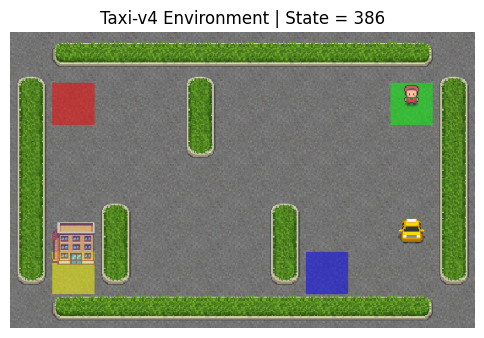

In [81]:
def make_taxi_env(render_mode=None):

    for env_id in ("Taxi-v4", "Taxi-v3"):
        try:
            return gym.make(env_id, render_mode=render_mode), env_id
        except Exception:
            continue

    raise RuntimeError("Taxi environment was not found.")


env, ENV_ID = make_taxi_env(render_mode="rgb_array")

state, info = env.reset(seed=SEED)

print("Environment:", ENV_ID)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Initial encoded state:", state)

frame = env.render()

plt.figure(figsize=(6, 6))
plt.imshow(frame)
plt.axis("off")
plt.title(f"{ENV_ID} Environment | State = {state}")
plt.show()

## 11.1 Decode an Encoded Taxi State

The environment stores the complete situation as one integer.

We can decode that integer into:

$$
(\text{taxi row},\text{taxi column},\text{passenger location},\text{destination}).
$$

In [82]:
decoded = tuple(env.unwrapped.decode(state))

print("Encoded state:", state)
print("Decoded state:", decoded)
print("(taxi_row, taxi_col, passenger_location, destination)")

Encoded state: 386
Decoded state: (3, 4, 1, 2)
(taxi_row, taxi_col, passenger_location, destination)


# 12. Helper Functions

The next cells define:

- $\epsilon$-greedy action selection,
- $\epsilon$-greedy action probabilities,
- the training functions for all three algorithms,
- update logging,
- episode-return tracking,
- Q-table convergence tracking.

In [83]:
ACTION_NAMES = ["South", "North", "East", "West", "Pickup", "Dropoff"]

def epsilon_greedy_action(q_table, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(q_table.shape[1]))
    best = np.flatnonzero(q_table[state] == np.max(q_table[state]))
    return int(rng.choice(best))

def epsilon_greedy_probabilities(q_row, epsilon):
    n_actions = len(q_row)
    probs = np.full(n_actions, epsilon / n_actions, dtype=float)
    best = np.flatnonzero(q_row == np.max(q_row))
    probs[best] += (1.0 - epsilon) / len(best)
    return probs

def epsilon_at_episode(episode, epsilon_start=1.0, epsilon_min=0.01, epsilon_decay=0.9995):
    return max(epsilon_min, epsilon_start * (epsilon_decay ** episode))

In [84]:
def train_q_learning(
    episodes=20000,
    alpha=0.10,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.9995,
    seed=42,
    log_updates=60
):
    env, _ = make_taxi_env()
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    q = np.zeros((n_states, n_actions), dtype=float)
    rng = np.random.default_rng(seed)

    rewards = []
    steps_history = []
    q_deltas = []
    logs = []
    update_number = 0

    for episode in range(episodes):
        epsilon = epsilon_at_episode(episode, epsilon_start, epsilon_min, epsilon_decay)
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0
        steps = 0
        q_before = q.copy()

        while True:
            action = epsilon_greedy_action(q, state, epsilon, rng)
            next_state, reward, terminated, truncated, _ = env.step(action)

            old_q = q[state, action]
            if terminated:
                target = reward
            else:
                target = reward + gamma * np.max(q[next_state])

            td_error = target - old_q
            q[state, action] = old_q + alpha * td_error

            update_number += 1
            if update_number <= log_updates:
                logs.append([
                    update_number, episode + 1, state, ACTION_NAMES[action], reward,
                    next_state, old_q, target, td_error, q[state, action], epsilon
                ])

            total_reward += reward
            steps += 1
            state = next_state

            if terminated or truncated:
                break

        rewards.append(total_reward)
        steps_history.append(steps)
        q_deltas.append(np.max(np.abs(q - q_before)))

    env.close()
    columns = [
        "Update", "Episode", "State", "Action", "Reward", "Next State",
        "Old Q", "TD Target", "TD Error", "New Q", "Epsilon"
    ]
    return q, np.array(rewards), np.array(steps_history), np.array(q_deltas), pd.DataFrame(logs, columns=columns)

In [85]:
def train_sarsa(
    episodes=20000,
    alpha=0.10,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.9995,
    seed=42,
    log_updates=60
):
    env, _ = make_taxi_env()
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    q = np.zeros((n_states, n_actions), dtype=float)
    rng = np.random.default_rng(seed)

    rewards = []
    steps_history = []
    q_deltas = []
    logs = []
    update_number = 0

    for episode in range(episodes):
        epsilon = epsilon_at_episode(episode, epsilon_start, epsilon_min, epsilon_decay)
        state, _ = env.reset(seed=seed + episode)
        action = epsilon_greedy_action(q, state, epsilon, rng)

        total_reward = 0
        steps = 0
        q_before = q.copy()

        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            old_q = q[state, action]

            if terminated:
                target = reward
                next_action = None
            else:
                next_action = epsilon_greedy_action(q, next_state, epsilon, rng)
                target = reward + gamma * q[next_state, next_action]

            td_error = target - old_q
            q[state, action] = old_q + alpha * td_error

            update_number += 1
            if update_number <= log_updates:
                next_action_name = "Terminal" if next_action is None else ACTION_NAMES[next_action]
                logs.append([
                    update_number, episode + 1, state, ACTION_NAMES[action], reward,
                    next_state, next_action_name, old_q, target, td_error,
                    q[state, action], epsilon
                ])

            total_reward += reward
            steps += 1

            if terminated or truncated:
                break

            state = next_state
            action = next_action

        rewards.append(total_reward)
        steps_history.append(steps)
        q_deltas.append(np.max(np.abs(q - q_before)))

    env.close()
    columns = [
        "Update", "Episode", "State", "Action", "Reward", "Next State",
        "Next Action", "Old Q", "TD Target", "TD Error", "New Q", "Epsilon"
    ]
    return q, np.array(rewards), np.array(steps_history), np.array(q_deltas), pd.DataFrame(logs, columns=columns)

In [86]:
def train_expected_sarsa(
    episodes=20000,
    alpha=0.10,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.9995,
    seed=42,
    log_updates=60
):
    env, _ = make_taxi_env()
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    q = np.zeros((n_states, n_actions), dtype=float)
    rng = np.random.default_rng(seed)

    rewards = []
    steps_history = []
    q_deltas = []
    logs = []
    update_number = 0

    for episode in range(episodes):
        epsilon = epsilon_at_episode(episode, epsilon_start, epsilon_min, epsilon_decay)
        state, _ = env.reset(seed=seed + episode)

        total_reward = 0
        steps = 0
        q_before = q.copy()

        while True:
            action = epsilon_greedy_action(q, state, epsilon, rng)
            next_state, reward, terminated, truncated, _ = env.step(action)
            old_q = q[state, action]

            if terminated:
                expected_q = 0.0
                target = reward
            else:
                probs = epsilon_greedy_probabilities(q[next_state], epsilon)
                expected_q = np.dot(probs, q[next_state])
                target = reward + gamma * expected_q

            td_error = target - old_q
            q[state, action] = old_q + alpha * td_error

            update_number += 1
            if update_number <= log_updates:
                logs.append([
                    update_number, episode + 1, state, ACTION_NAMES[action], reward,
                    next_state, expected_q, old_q, target, td_error,
                    q[state, action], epsilon
                ])

            total_reward += reward
            steps += 1
            state = next_state

            if terminated or truncated:
                break

        rewards.append(total_reward)
        steps_history.append(steps)
        q_deltas.append(np.max(np.abs(q - q_before)))

    env.close()
    columns = [
        "Update", "Episode", "State", "Action", "Reward", "Next State",
        "Expected Next Q", "Old Q", "TD Target", "TD Error", "New Q", "Epsilon"
    ]
    return q, np.array(rewards), np.array(steps_history), np.array(q_deltas), pd.DataFrame(logs, columns=columns)

# 13. Training Configuration

All three algorithms use the same:

- environment,
- number of episodes,
- learning rate,
- discount factor,
- exploration schedule,
- random seed.

Keeping these settings fixed makes the comparison easier to interpret.

In [87]:
EPISODES = 20000
ALPHA = 0.10
GAMMA = 0.95
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.9995

print("Episodes:", EPISODES)
print("Alpha:", ALPHA)
print("Gamma:", GAMMA)
print("Initial epsilon:", EPSILON_START)
print("Minimum epsilon:", EPSILON_MIN)
print("Epsilon decay:", EPSILON_DECAY)

Episodes: 20000
Alpha: 0.1
Gamma: 0.95
Initial epsilon: 1.0
Minimum epsilon: 0.01
Epsilon decay: 0.9995


# 14. Train Q-Learning, SARSA, and Expected SARSA

In [88]:
q_ql, rewards_ql, steps_ql, delta_ql, log_ql = train_q_learning(
    episodes=EPISODES, alpha=ALPHA, gamma=GAMMA,
    epsilon_start=EPSILON_START, epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY, seed=SEED
)

q_sarsa, rewards_sarsa, steps_sarsa, delta_sarsa, log_sarsa = train_sarsa(
    episodes=EPISODES, alpha=ALPHA, gamma=GAMMA,
    epsilon_start=EPSILON_START, epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY, seed=SEED
)

q_esarsa, rewards_esarsa, steps_esarsa, delta_esarsa, log_esarsa = train_expected_sarsa(
    episodes=EPISODES, alpha=ALPHA, gamma=GAMMA,
    epsilon_start=EPSILON_START, epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY, seed=SEED
)

print("Training complete.")

Training complete.


# 15. First 60 Q-Value Updates

A final Q-table does not show how learning occurred.

The next cells display the first **60 individual updates** for each algorithm.

For SARSA, notice the explicit `Next Action` column. That action is part of the SARSA target:

$$
R_{t+1}+\gamma Q(S_{t+1},A_{t+1}).
$$

In [89]:
display(log_sarsa)

,Update,Episode,State,Action,Reward,Next State,Next Action,Old Q,TD Target,TD Error,New Q,Epsilon
0,1,1,386,West,-1,366,East,0.000,-1.000,-1.000,-0.100,1.0
1,2,1,366,East,-1,386,North,0.000,-1.000,-1.000,-0.100,1.0
2,3,1,386,North,-1,286,South,0.000,-1.000,-1.000,-0.100,1.0
3,4,1,286,South,-1,386,Pickup,0.000,-1.000,-1.000,-0.100,1.0
4,5,1,386,Pickup,-10,386,Pickup,0.000,-10.000,-10.000,-1.000,1.0
5,6,1,386,Pickup,-10,386,West,-1.000,-10.095,-9.095,-1.909,1.0
6,7,1,386,West,-1,366,East,-0.100,-1.095,-0.995,-0.200,1.0
7,8,1,366,East,-1,386,East,-0.100,-1.000,-0.900,-0.190,1.0
8,9,1,386,East,-1,386,Pickup,0.000,-2.814,-2.814,-0.281,1.0
9,10,1,386,Pickup,-10,386,South,-1.909,-10.000,-8.091,-2.719,1.0


### First 60 Q-Learning updates

In [90]:
display(log_ql)

,Update,Episode,State,Action,Reward,Next State,Old Q,TD Target,TD Error,New Q,Epsilon
0,1,1,386,West,-1,366,0.000,-1.000,-1.000,-0.100,1.0
1,2,1,366,East,-1,386,0.000,-1.000,-1.000,-0.100,1.0
2,3,1,386,North,-1,286,0.000,-1.000,-1.000,-0.100,1.0
3,4,1,286,South,-1,386,0.000,-1.000,-1.000,-0.100,1.0
4,5,1,386,Pickup,-10,386,0.000,-10.000,-10.000,-1.000,1.0
5,6,1,386,Pickup,-10,386,-1.000,-10.000,-9.000,-1.900,1.0
6,7,1,386,West,-1,366,-0.100,-1.000,-0.900,-0.190,1.0
7,8,1,366,East,-1,386,-0.100,-1.000,-0.900,-0.190,1.0
8,9,1,386,East,-1,386,0.000,-1.000,-1.000,-0.100,1.0
9,10,1,386,Pickup,-10,386,-1.900,-10.000,-8.100,-2.710,1.0


### First 60 Expected SARSA updates

In [91]:
display(log_esarsa)

,Update,Episode,State,Action,Reward,Next State,Expected Next Q,Old Q,TD Target,TD Error,New Q,Epsilon
0,1,1,386,West,-1,366,0.000,0.000,-1.000,-1.000,-0.100,1.0
1,2,1,366,East,-1,386,-0.017,0.000,-1.016,-1.016,-0.102,1.0
2,3,1,386,North,-1,286,0.000,0.000,-1.000,-1.000,-0.100,1.0
3,4,1,286,South,-1,386,-0.033,0.000,-1.032,-1.032,-0.103,1.0
4,5,1,386,Pickup,-10,386,-0.033,0.000,-10.032,-10.032,-1.003,1.0
5,6,1,386,Pickup,-10,386,-0.201,-1.003,-10.191,-9.187,-1.922,1.0
6,7,1,386,West,-1,366,-0.017,-0.100,-1.016,-0.916,-0.192,1.0
7,8,1,366,East,-1,386,-0.369,-0.102,-1.350,-1.249,-0.226,1.0
8,9,1,386,East,-1,386,-0.369,0.000,-1.350,-1.350,-0.135,1.0
9,10,1,386,Pickup,-10,386,-0.391,-1.922,-10.372,-8.450,-2.767,1.0


# 16. Reward vs. Episode

For episode $e$, the total return is

$$
G_e=\sum_t R_{t+1}.
$$

Because individual episode returns can be noisy, the figure shows a moving average.

A rising curve indicates that the agent is learning to complete the Taxi task using fewer penalties and fewer unnecessary actions.

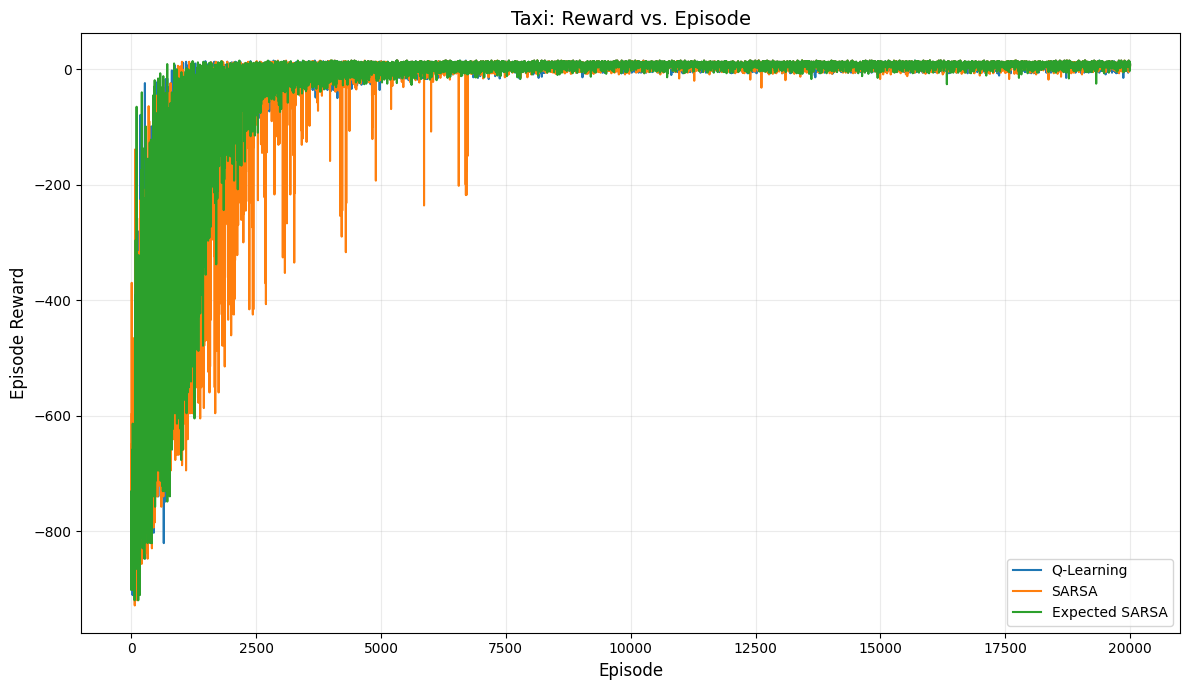

In [103]:
plt.figure(figsize=(12, 7))

plt.plot(rewards_ql, label="Q-Learning")
plt.plot(rewards_sarsa, label="SARSA")
plt.plot(rewards_esarsa, label="Expected SARSA")

plt.xlabel("Episode", fontsize=12)
plt.ylabel("Episode Reward", fontsize=12)
plt.title("Taxi: Reward vs. Episode", fontsize=14)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

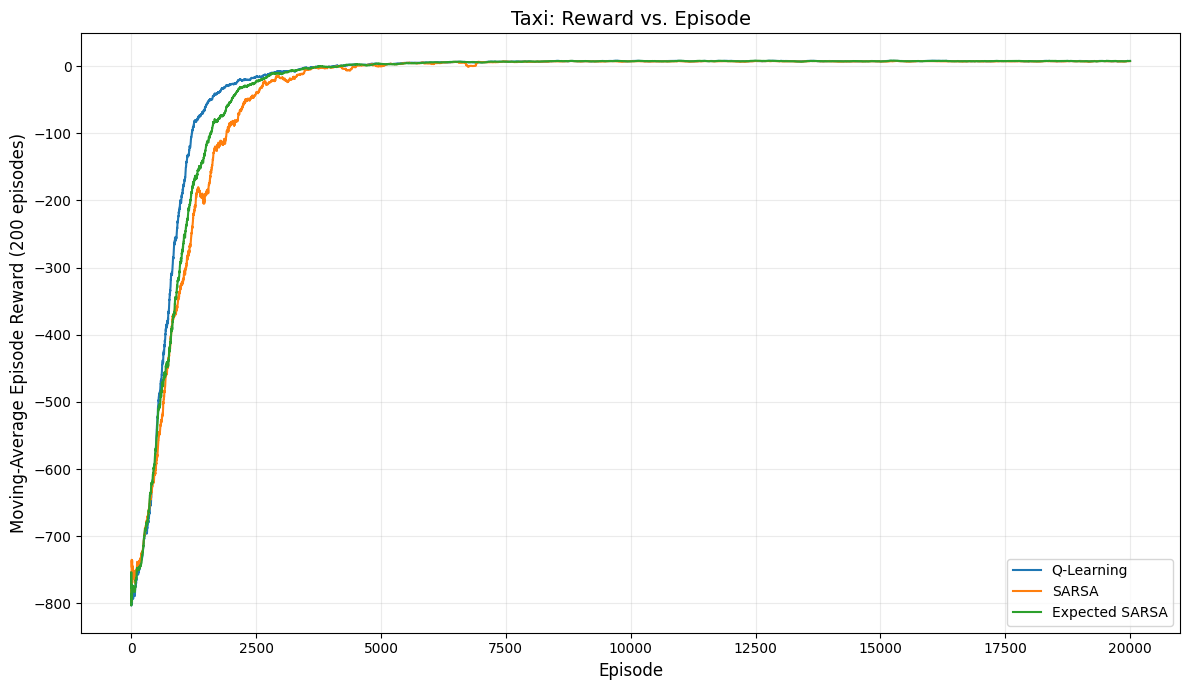

In [92]:
def moving_average(values, window=200):
    return pd.Series(values).rolling(window, min_periods=1).mean().to_numpy()

window = 200

plt.figure(figsize=(12, 7))
plt.plot(moving_average(rewards_ql, window), label="Q-Learning")
plt.plot(moving_average(rewards_sarsa, window), label="SARSA")
plt.plot(moving_average(rewards_esarsa, window), label="Expected SARSA")
plt.xlabel("Episode", fontsize=12)
plt.ylabel(f"Moving-Average Episode Reward ({window} episodes)", fontsize=12)
plt.title("Taxi: Reward vs. Episode", fontsize=14)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 17. Q-Table Convergence

To track Q-table stabilization, after each episode we calculate

$$
\Delta Q_e
=
\max_{s,a}
\left|
Q_e(s,a)-Q_{e-1}(s,a)
\right|.
$$

Large values mean at least one state-action estimate changed substantially during that episode.

As learning stabilizes, $\Delta Q_e$ should generally become small.

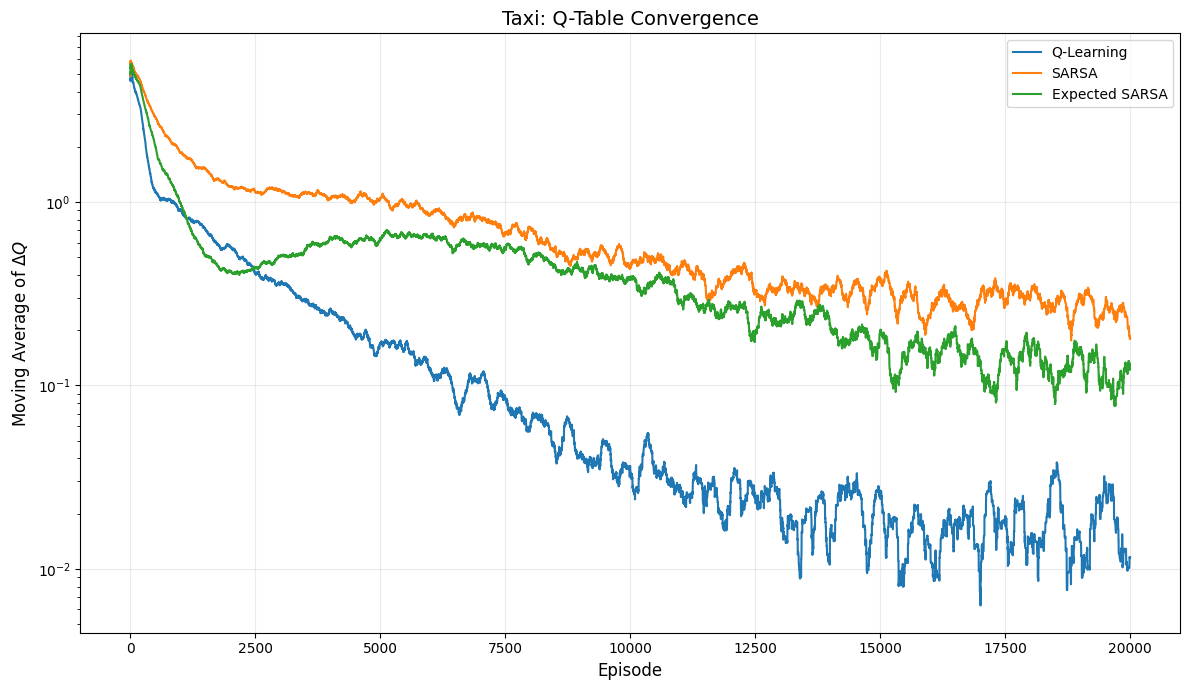

In [93]:
window = 200

plt.figure(figsize=(12, 7))
plt.plot(moving_average(delta_ql, window), label="Q-Learning")
plt.plot(moving_average(delta_sarsa, window), label="SARSA")
plt.plot(moving_average(delta_esarsa, window), label="Expected SARSA")
plt.xlabel("Episode", fontsize=12)
plt.ylabel(r"Moving Average of $\Delta Q$", fontsize=12)
plt.title("Taxi: Q-Table Convergence", fontsize=14)
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 18. Final Learned Q-Tables

Each Taxi Q-table has

$$
500\times6=3000
$$

state-action values.

A finite training run produces a **learned Q-table**. It is better to use this term than to automatically call every learned table the exact mathematical $Q^*$.

The next cells create the complete tables, display a portfolio-friendly sample, and save the full tables as CSV files.

In [94]:
def q_table_dataframe(q):
    df = pd.DataFrame(q, columns=ACTION_NAMES)
    df.index.name = "State"
    return df

q_df_ql = q_table_dataframe(q_ql)
q_df_sarsa = q_table_dataframe(q_sarsa)
q_df_esarsa = q_table_dataframe(q_esarsa)

q_df_ql.to_csv("q_table_q_learning.csv")
q_df_sarsa.to_csv("q_table_sarsa.csv")
q_df_esarsa.to_csv("q_table_expected_sarsa.csv")

print("Q-Learning Q-table shape:", q_df_ql.shape)
print("SARSA Q-table shape:", q_df_sarsa.shape)
print("Expected SARSA Q-table shape:", q_df_esarsa.shape)
print("Full Q-tables saved as CSV files.")

Q-Learning Q-table shape: (500, 6)
SARSA Q-table shape: (500, 6)
Expected SARSA Q-table shape: (500, 6)
Full Q-tables saved as CSV files.


## 18.1 Q-Learning Final Q-Table Sample

In [95]:
display(q_df_ql.head(30))

,South,North,East,West,Pickup,Dropoff
State,,,,,,
0,0.000,0.000,0.000,0.000,0.000,0.000
1,1.455,2.915,1.555,3.509,5.210,-5.344
2,7.528,9.115,7.263,9.307,10.951,-0.023
3,2.559,4.690,2.875,3.814,6.537,-5.031
4,-3.294,-6.866,-6.803,-6.835,-15.419,-15.089
5,0.000,0.000,0.000,0.000,0.000,0.000
6,-3.302,-6.711,-6.858,-6.832,-15.312,-14.946
7,-6.276,-6.298,-0.559,-6.408,-15.005,-14.776
8,5.194,-3.971,-4.158,-4.182,-12.846,-12.984


## 18.2 SARSA Final Q-Table Sample

In [96]:
display(q_df_sarsa.head(30))

,South,North,East,West,Pickup,Dropoff
State,,,,,,
0,0.000,0.000,0.000,0.000,0.000,0.000
1,-11.689,-9.170,-16.145,-10.695,4.624,-17.901
2,-4.082,-9.496,-5.127,-0.429,10.868,-10.839
3,-6.668,-7.971,-11.378,-7.419,6.329,-18.671
4,-5.063,-24.370,-24.256,-24.579,-31.946,-32.083
5,0.000,0.000,0.000,0.000,0.000,0.000
6,-6.257,-26.657,-26.245,-26.184,-33.298,-34.810
7,-20.750,-20.791,-2.916,-20.689,-27.299,-26.001
8,3.723,-19.827,-20.135,-20.440,-26.918,-27.111


## 18.3 Expected SARSA Final Q-Table Sample

In [97]:
display(q_df_esarsa.head(30))

,South,North,East,West,Pickup,Dropoff
State,,,,,,
0,0.000,0.000,0.000,0.000,0.000,0.000
1,-10.679,-8.483,-7.587,-5.805,4.483,-17.057
2,-4.212,-4.107,-7.332,-2.193,10.579,-7.790
3,-11.556,-10.566,-11.914,-9.890,5.835,-13.755
4,-5.238,-21.870,-21.705,-21.871,-29.232,-29.679
5,0.000,0.000,0.000,0.000,0.000,0.000
6,-23.682,-23.689,-5.987,-23.692,-31.844,-31.290
7,-2.869,-19.156,-19.163,-19.173,-25.876,-26.995
8,4.221,-15.949,-19.521,-19.586,-26.599,-27.088


### Optional: display all 500 rows

Set `SHOW_FULL_Q_TABLES = True` if you want the notebook to print every row of all three Q-tables.

The CSV files always contain the complete tables.

In [98]:
SHOW_FULL_Q_TABLES = False

if SHOW_FULL_Q_TABLES:
    with pd.option_context("display.max_rows", 500):
        print("Q-Learning")
        display(q_df_ql)
        print("SARSA")
        display(q_df_sarsa)
        print("Expected SARSA")
        display(q_df_esarsa)

# 19. Extract the Greedy Policy

After training, a greedy policy can be obtained from each Q-table using

$$
\pi(s)=\arg\max_a Q(s,a).
$$

The greedy policy is used for evaluation, so exploration is turned off.

In [99]:
policy_ql = np.argmax(q_ql, axis=1)
policy_sarsa = np.argmax(q_sarsa, axis=1)
policy_esarsa = np.argmax(q_esarsa, axis=1)

policy_sample = pd.DataFrame({
    "State": np.arange(30),
    "Q-Learning": [ACTION_NAMES[a] for a in policy_ql[:30]],
    "SARSA": [ACTION_NAMES[a] for a in policy_sarsa[:30]],
    "Expected SARSA": [ACTION_NAMES[a] for a in policy_esarsa[:30]]
}).set_index("State")

display(policy_sample)

,Q-Learning,SARSA,Expected SARSA
State,,,
0,South,South,South
1,Pickup,Pickup,Pickup
2,Pickup,Pickup,Pickup
3,Pickup,Pickup,Pickup
4,South,South,South
5,South,South,South
6,South,South,East
7,East,East,South
8,South,South,South


# 20. Evaluate the Three Trained Agents

Training reward alone is not enough for comparison because training includes exploration.

We therefore evaluate each final Q-table using a **greedy policy**:

$$
A_t=\arg\max_a Q(S_t,a).
$$

The evaluation reports:

- mean episode reward,
- success rate,
- mean number of steps,
- mean illegal pickup/drop-off penalties.

The algorithm with the highest mean evaluation reward is selected for the final simulation. Ties are broken by success rate and then by fewer steps.

In [100]:
def evaluate_agent(q_table, episodes=1000, seed=10000):
    env, _ = make_taxi_env()
    rng = np.random.default_rng(seed)

    episode_rewards = []
    episode_steps = []
    successes = []
    illegal_counts = []

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0
        illegal = 0
        success = 0

        for step in range(1, 201):
            best = np.flatnonzero(q_table[state] == np.max(q_table[state]))
            action = int(rng.choice(best))

            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            illegal += int(reward == -10)
            state = next_state

            if terminated:
                success = 1
                break

            if truncated:
                break

        episode_rewards.append(total_reward)
        episode_steps.append(step)
        successes.append(success)
        illegal_counts.append(illegal)

    env.close()

    return {
        "Mean Reward": np.mean(episode_rewards),
        "Success Rate": np.mean(successes),
        "Mean Steps": np.mean(episode_steps),
        "Mean Illegal Actions": np.mean(illegal_counts)
    }

results = []
for name, q_table in {
    "Q-Learning": q_ql,
    "SARSA": q_sarsa,
    "Expected SARSA": q_esarsa
}.items():
    metrics = evaluate_agent(q_table)
    metrics["Algorithm"] = name
    results.append(metrics)

evaluation_df = pd.DataFrame(results)[
    ["Algorithm", "Mean Reward", "Success Rate", "Mean Steps", "Mean Illegal Actions"]
]

display(evaluation_df)

,Algorithm,Mean Reward,Success Rate,Mean Steps,Mean Illegal Actions
0,Q-Learning,7.911,1.0,13.089,0.0
1,SARSA,7.611,1.0,13.389,0.0
2,Expected SARSA,7.911,1.0,13.089,0.0


# 21. Select the Best-Performing Trained Agent

For this notebook, **best-performing** means:

1. highest mean evaluation reward,
2. then highest success rate if needed,
3. then fewer mean steps if another tie remains.

This is an empirical comparison for this training configuration and random seed, not a universal claim that one TD algorithm is always superior.

In [101]:
ranking = evaluation_df.sort_values(
    by=["Mean Reward", "Success Rate", "Mean Steps"],
    ascending=[False, False, True]
).reset_index(drop=True)

best_name = ranking.loc[0, "Algorithm"]

q_tables = {
    "Q-Learning": q_ql,
    "SARSA": q_sarsa,
    "Expected SARSA": q_esarsa
}

best_q = q_tables[best_name]

print("Selected algorithm:", best_name)
display(ranking)

Selected algorithm: Q-Learning


,Algorithm,Mean Reward,Success Rate,Mean Steps,Mean Illegal Actions
0,Q-Learning,7.911,1.0,13.089,0.0
1,Expected SARSA,7.911,1.0,13.089,0.0
2,SARSA,7.611,1.0,13.389,0.0


# 22. Simulate One Episode Using the Selected Agent

The final simulation uses the selected Q-table with a greedy policy.

No exploration is used:

$$
A_t=\arg\max_a Q(S_t,a).
$$

The cell records every rendered frame and creates a GIF so the learned policy can be viewed directly in Colab.

Algorithm: Q-Learning
Environment: Taxi-v4
Simulation reward: 14
Number of actions: 7


,Step,State,Action,Reward,Next State,Terminated,Truncated
0,1,87,Pickup,-1,99,False,False
1,2,99,South,-1,199,False,False
2,3,199,South,-1,299,False,False
3,4,299,South,-1,399,False,False
4,5,399,South,-1,499,False,False
5,6,499,West,-1,479,False,False
6,7,479,Dropoff,20,475,True,False


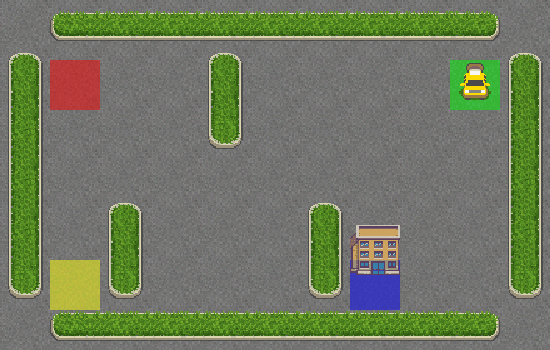

In [104]:
def simulate_and_save_gif(q_table, filename="best_taxi_simulation.gif", seed=2026, fps=2):
    env, env_id = make_taxi_env(render_mode="rgb_array")
    state, _ = env.reset(seed=seed)
    rng = np.random.default_rng(seed)

    frames = [env.render()]
    trace = []
    total_reward = 0

    for step in range(1, 201):
        best = np.flatnonzero(q_table[state] == np.max(q_table[state]))
        action = int(rng.choice(best))

        next_state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

        trace.append([
            step, state, ACTION_NAMES[action], reward, next_state,
            terminated, truncated
        ])

        state = next_state
        frames.append(env.render())

        if terminated or truncated:
            break

    env.close()

    imageio.mimsave(filename, frames, fps=fps)

    trace_df = pd.DataFrame(
        trace,
        columns=[
            "Step", "State", "Action", "Reward",
            "Next State", "Terminated", "Truncated"
        ]
    )

    return filename, trace_df, total_reward, env_id

gif_file, simulation_trace, simulation_reward, simulation_env_id = simulate_and_save_gif(best_q)

print("Algorithm:", best_name)
print("Environment:", simulation_env_id)
print("Simulation reward:", simulation_reward)
print("Number of actions:", len(simulation_trace))
display(simulation_trace)
display(Image(filename=gif_file))

# 23. What the Comparison Means

The three methods use the same basic TD idea but answer a different question at the next state.

### Q-Learning

$$
R_{t+1}+\gamma\max_aQ(S_{t+1},a)
$$

asks:

> What would the return look like if I behaved greedily from the next state?

### SARSA

$$
R_{t+1}+\gamma Q(S_{t+1},A_{t+1})
$$

asks:

> What is the value of the next action my current policy actually selected?

### Expected SARSA

$$
R_{t+1}
+
\gamma
\sum_a
\pi(a|S_{t+1})Q(S_{t+1},a)
$$

asks:

> What is the expected next-state action value under my target policy?

That single difference in the bootstrap target creates the main distinction among the three algorithms.

# 24. Reinforcement Learning in General Perspective

The algorithms in this notebook belong to one branch of the larger reinforcement learning family.

A useful high-level organization is:

```text
Reinforcement Learning
│
├── Model-Based RL
│   │
│   ├── Learn or use environment dynamics
│   │
│   └── Planning methods can use the learned model
│
└── Model-Free RL
    │
    ├── Tabular Methods
    │   │
    │   ├── Monte Carlo
    │   │
    │   │   ├── First-Visit MC
    │   │   │   ├── Every-Visit MC
    │   │   │   ├── Exploring Starts
    │   │   │   └── MC Control with epsilon-greedy policies
    │   │   │
    │   │   └── Temporal-Difference Learning
    │   │       ├── TD(0)
    │   │       ├── SARSA
    │   │       ├── Expected SARSA
    │   │       └── Q-Learning
    │   │
    │   └── Function Approximation
    │       ├── Deep Q-Learning
    │       ├── Policy Gradient
    │       ├── Actor-Critic
    │       ├── DDPG
    │       └── PPO
```

Another important branch is **Dynamic Programming**, which applies when the environment model is known.

```text
Known transition model and reward model
        ↓
Dynamic Programming
        ↓
Policy Evaluation / Policy Iteration / Value Iteration

Unknown model, but interaction experience is available
        ↓
Model-Free Reinforcement Learning
        ↓
Monte Carlo or Temporal-Difference Learning
```



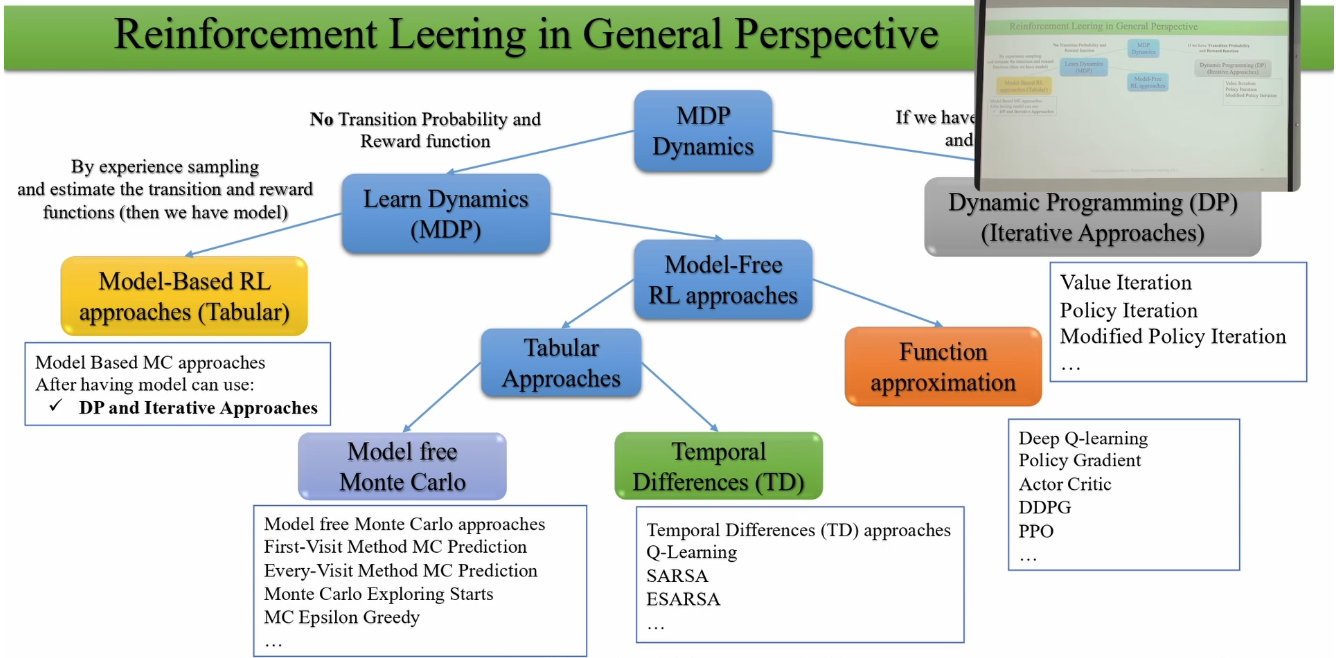